In [1]:
import os
import certifi

os.environ["SSL_CERT_FILE"] = certifi.where()

In [2]:
import numpy as np
import os
import certifi
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms
os.environ["SSL_CERT_FILE"] = certifi.where()

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

In [4]:
train_data = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_data = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_data, batch_size=4, shuffle=True, num_workers=2)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=4, shuffle=False, num_workers=2)

100.0%


In [5]:
image, label = train_data[0]

In [6]:
image.size()

torch.Size([3, 32, 32])

In [7]:
class_names = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

In [8]:
class NeuralNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 12, 5) # (32 - 5) + 1 = 28
        self.pool = nn.MaxPool2d(2,2)
        self.conv2 = nn.Conv2d(12,24,5)
        self.fc1 = nn.Linear(24*5*5, 120)
        self.fc2 = nn.Linear(120,84)
        self.fc3 = nn.Linear(84,10)
        

    def forward(self,x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x,1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


In [9]:
net = NeuralNet()
loss_function = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

In [11]:
for epoch in range(30):
    print(f"Training epoch {epoch} ...")
    running_loss = 0.0
    for i, data in enumerate(train_loader,0):
        inputs, labels = data
        optimizer.zero_grad()
        outputs = net(inputs)
        loss = loss_function(outputs,labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Loss after epoch {epoch}: {running_loss/len(train_loader)}")

        

Training epoch 0 ...


Loss after epoch 0: 0.4227114377797038
Training epoch 1 ...
Loss after epoch 1: 0.42625453908966715
Training epoch 2 ...
Loss after epoch 2: 0.42374631577667476
Training epoch 3 ...
Loss after epoch 3: 0.4192376366696063
Training epoch 4 ...
Loss after epoch 4: 0.4195020163873447
Training epoch 5 ...
Loss after epoch 5: 0.4256303300097196
Training epoch 6 ...
Loss after epoch 6: 0.42422949223949835
Training epoch 7 ...
Loss after epoch 7: 0.41969187650909573
Training epoch 8 ...
Loss after epoch 8: 0.44004815418499643
Training epoch 9 ...
Loss after epoch 9: 0.4149913130655435
Training epoch 10 ...
Loss after epoch 10: 0.4200773591332994
Training epoch 11 ...
Loss after epoch 11: 0.42091539387303056
Training epoch 12 ...
Loss after epoch 12: 0.4184915490341017
Training epoch 13 ...
Loss after epoch 13: 0.4393396934802996
Training epoch 14 ...
Loss after epoch 14: 0.4315838735797099
Training epoch 15 ...
Loss after epoch 15: 0.4349626615609647
Training epoch 16 ...
Loss after epoch 16: 

In [12]:
torch.save(net.state_dict(), "trained_net.pth")

In [13]:
net = NeuralNet()
net.load_state_dict(torch.load("trained_net.pth"))

<All keys matched successfully>

In [25]:
net.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = net(images)
        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

print(f"Test accuracy: {100 * correct / total:.2f}%")

Test accuracy: 60.27%


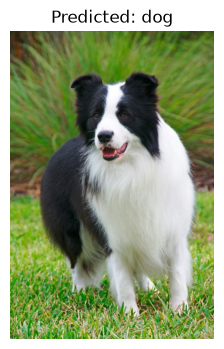

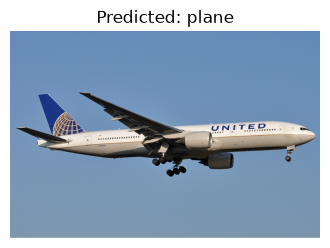

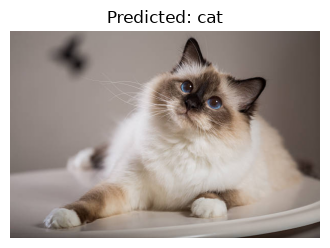

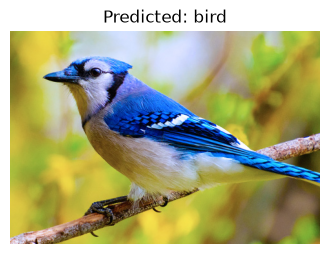

In [31]:
from PIL import Image
from matplotlib import pyplot as plt
new_transform = transforms.Compose([
    transforms.Resize((32,32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5)),
])

def load_image(image_path):
    image = Image.open(image_path)
    image = new_transform(image)
    image = image.unsqueeze(0) 
    return image

image_path = ["example1.jpg", 'example2.jpg', 'example3.jpg','example4.jpg']
images = [load_image(path) for path in image_path]

net.eval()

with torch.no_grad():
    for path, image in zip(image_path, images):
        output = net(image)
        predicted = output.argmax(dim=1).item()
        predicted_class = class_names[predicted]

        plt.figure(figsize=(4, 4))
        plt.imshow(Image.open(path).convert("RGB"))
        plt.title(f"Predicted: {predicted_class}")
        plt.axis("off")
        plt.show()